In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print("Librerías cargadas correctamente")

TensorFlow version: 2.21.0
Librerías cargadas correctamente


In [3]:
# Explorar estructura del dataset
ruta_base = 'C:/Users/josem/brain-mri'

for carpeta in os.listdir(ruta_base):
    ruta_carpeta = os.path.join(ruta_base, carpeta)
    if os.path.isdir(ruta_carpeta):
        n_imagenes = len(os.listdir(ruta_carpeta))
        print(f"{carpeta}: {n_imagenes} imágenes")

brain_tumor_dataset: 2 imágenes
no: 98 imágenes
yes: 155 imágenes


In [4]:
ruta_yes = 'C:/Users/josem/brain-mri/yes'
ruta_no = 'C:/Users/josem/brain-mri/no'

# Cargar imágenes
def cargar_imagenes(ruta, etiqueta, tamaño=(128, 128)):
    imagenes = []
    etiquetas = []
    for archivo in os.listdir(ruta):
        if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = cv2.imread(os.path.join(ruta, archivo))
            if img is not None:
                img = cv2.resize(img, tamaño)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                imagenes.append(img)
                etiquetas.append(etiqueta)
    return imagenes, etiquetas

imgs_tumor, labs_tumor = cargar_imagenes(ruta_yes, 1)
imgs_normal, labs_normal = cargar_imagenes(ruta_no, 0)

X = np.array(imgs_tumor + imgs_normal) / 255.0
y = np.array(labs_tumor + labs_normal)

print(f"Imágenes con tumor: {len(imgs_tumor)}")
print(f"Imágenes normales: {len(imgs_normal)}")
print(f"Shape del dataset: {X.shape}")

Imágenes con tumor: 155
Imágenes normales: 98
Shape del dataset: (253, 128, 128, 3)


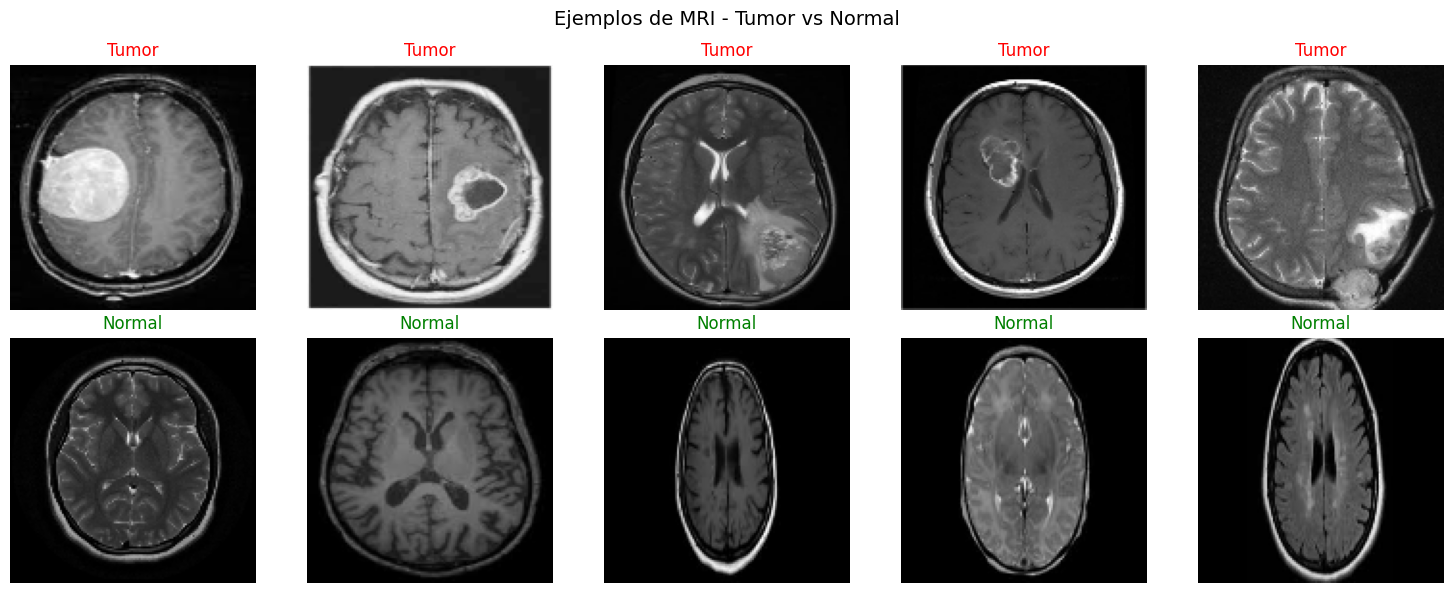

In [5]:
# Visualizar ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Ejemplos de MRI - Tumor vs Normal', fontsize=14)

# Imágenes con tumor
for i in range(5):
    axes[0, i].imshow(imgs_tumor[i])
    axes[0, i].set_title('Tumor', color='red')
    axes[0, i].axis('off')

# Imágenes normales
for i in range(5):
    axes[1, i].imshow(imgs_normal[i])
    axes[1, i].set_title('Normal', color='green')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('mri_examples.png', dpi=150)
plt.show()

In [6]:
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Construir CNN
modelo = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,517,185 (24.86 MB)

 Trainable params: 6,516,737 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# Entrenar la CNN
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history = modelo.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("Entrenamiento completado")

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.6646 - loss: 6.3356 - val_accuracy: 0.6829 - val_loss: 0.6971
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.6708 - loss: 2.8764 - val_accuracy: 0.4634 - val_loss: 3.1798
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step - accuracy: 0.7950 - loss: 1.0352 - val_accuracy: 0.3415 - val_loss: 5.6481
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.7640 - loss: 1.2267 - val_accuracy: 0.2683 - val_loss: 6.1274
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.8075 - loss: 0.9622 - val_accuracy: 0.2195 - val_loss: 7.8913
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.8758 - loss: 0.4123 - val_accuracy: 0.2683 - val_loss: 5.2125
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.8758 - loss: 0.4160 - val_accuracy: 0.3659 - val_loss: 4.0770
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.9255 - loss: 0.3208 - val_accuracy: 0.

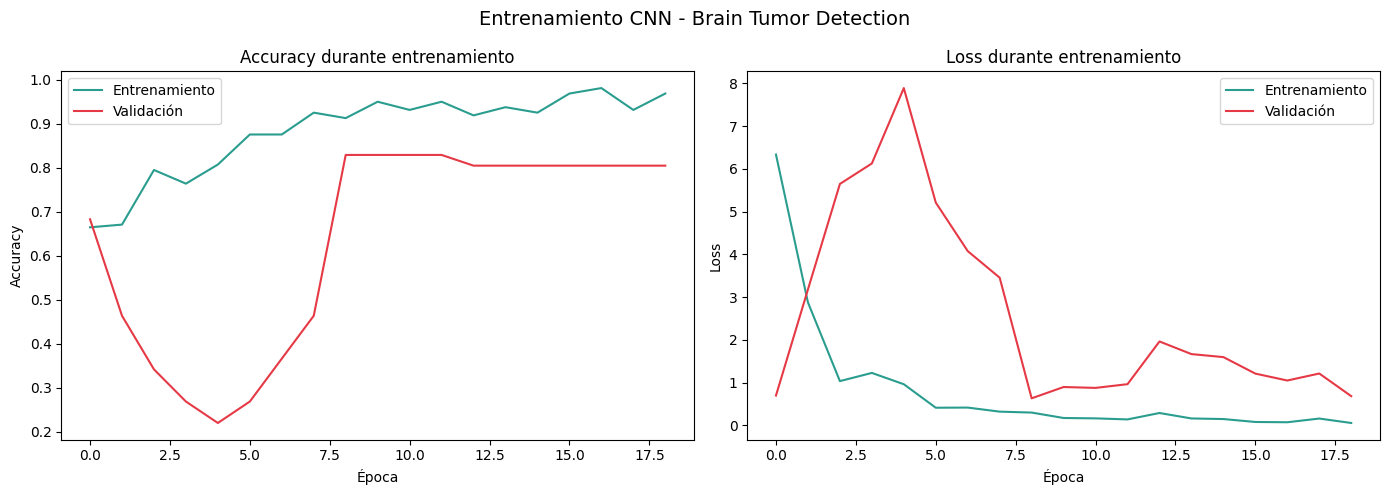

In [8]:
# Visualizar entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Entrenamiento CNN - Brain Tumor Detection', fontsize=14)

# Accuracy
axes[0].plot(history.history['accuracy'], color='#2a9d8f', label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], color='#e63946', label='Validación')
axes[0].set_title('Accuracy durante entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], color='#2a9d8f', label='Entrenamiento')
axes[1].plot(history.history['val_loss'], color='#e63946', label='Validación')
axes[1].set_title('Loss durante entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

Accuracy en test: 0.667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


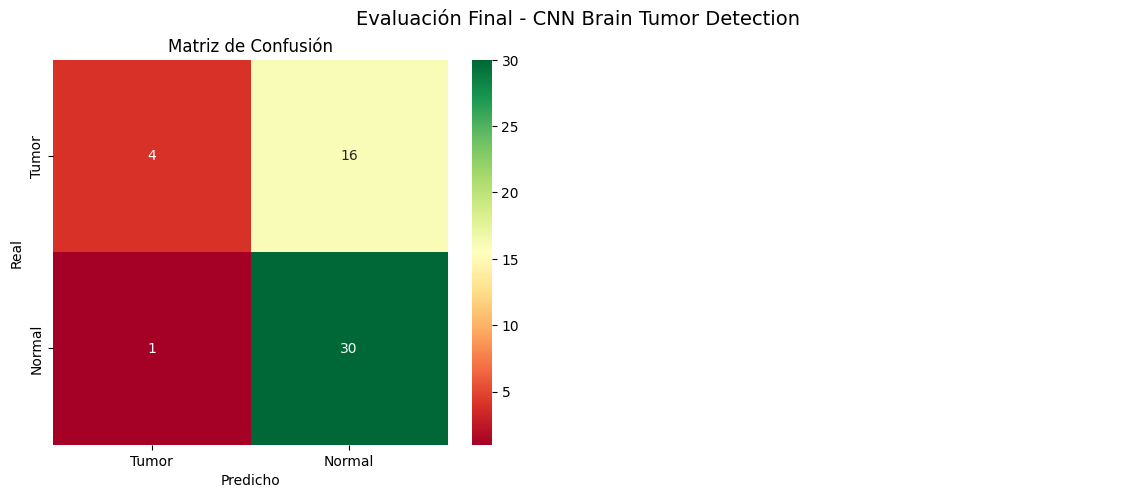

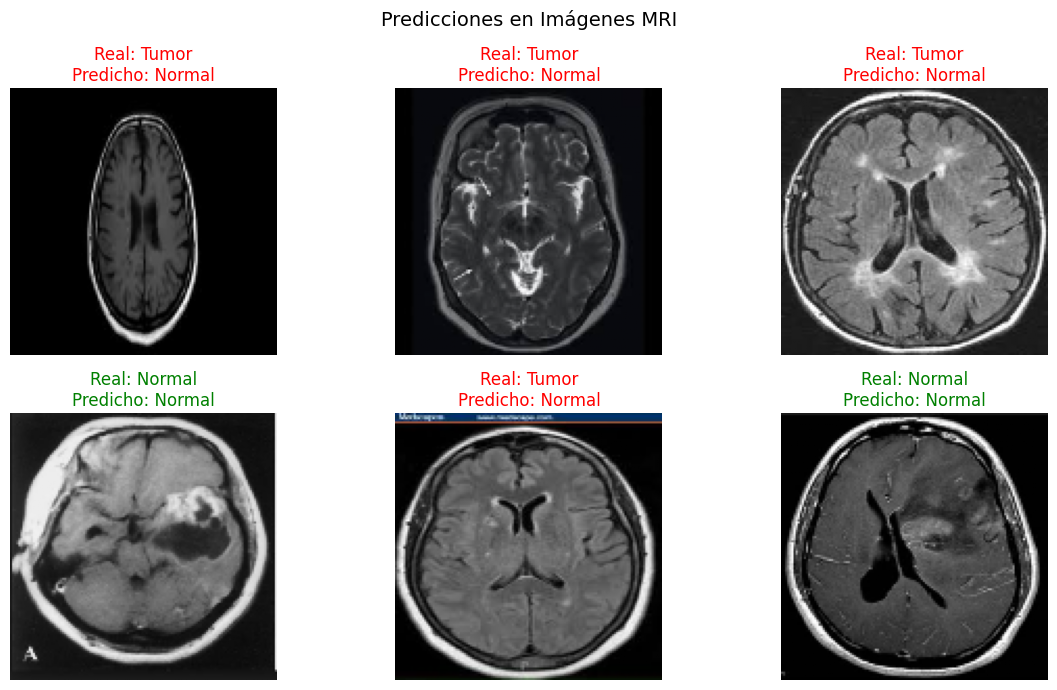


Reporte completo:
              precision    recall  f1-score   support

       Tumor       0.80      0.20      0.32        20
      Normal       0.65      0.97      0.78        31

    accuracy                           0.67        51
   macro avg       0.73      0.58      0.55        51
weighted avg       0.71      0.67      0.60        51



In [9]:
# Evaluación final
loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy:.3f}")

y_pred = (modelo.predict(X_test) > 0.5).astype(int).flatten()

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación Final - CNN Brain Tumor Detection', fontsize=14)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Tumor', 'Normal'],
            yticklabels=['Tumor', 'Normal'], ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Mostrar predicciones en imágenes reales
indices = np.random.choice(len(X_test), 6, replace=False)
axes[1].axis('off')
fig2, axs = plt.subplots(2, 3, figsize=(12, 7))
fig2.suptitle('Predicciones en Imágenes MRI', fontsize=14)

for i, idx in enumerate(indices):
    ax = axs[i//3, i%3]
    ax.imshow(X_test[idx])
    real = 'Tumor' if y_test[idx] == 0 else 'Normal'
    pred = 'Tumor' if y_pred[idx] == 0 else 'Normal'
    color = 'green' if real == pred else 'red'
    ax.set_title(f'Real: {real}\nPredicho: {pred}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

print("\nReporte completo:")
print(classification_report(y_test, y_pred, target_names=['Tumor', 'Normal']))

In [10]:
# Reiniciar con Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Nuevo modelo más simple para evitar overfitting
tf.keras.backend.clear_session()

modelo2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

modelo2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

early_stopping2 = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

history2 = modelo2.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping2],
    verbose=1
)

print("Entrenamiento completado")


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.6287 - loss: 1.0651 - val_accuracy: 0.6667 - val_loss: 0.6186
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.6188 - loss: 0.6521 - val_accuracy: 0.7843 - val_loss: 0.6189
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.6931 - loss: 0.6046 - val_accuracy: 0.7843 - val_loss: 0.4619
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.7327 - loss: 0.5762 - val_accuracy: 0.7843 - val_loss: 0.5185
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.7525 - loss: 0.5748 - val_accuracy: 0.8235 - val_loss: 0.4562
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.7327 - loss: 0.5513 - val_accuracy: 0.8039 - val_loss: 0.4503
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.7525 - loss: 0.5537 - val_accuracy: 0.7647 - val_loss: 0.4661
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.7327 - loss: 0.5709 - val_accuracy: 0

Accuracy en test: 0.824
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


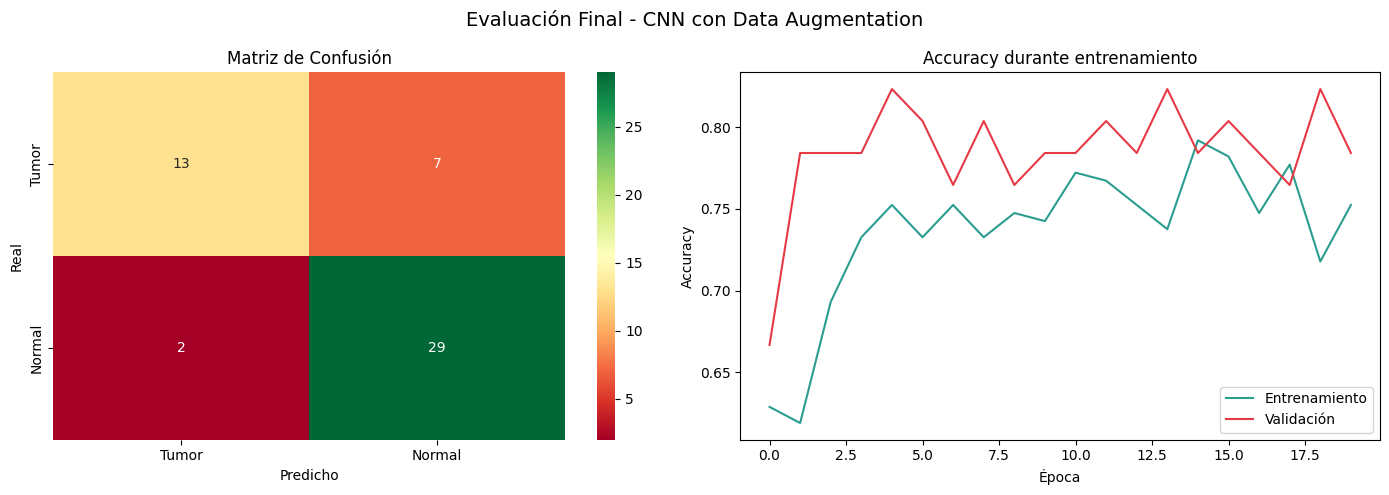


Reporte completo:
              precision    recall  f1-score   support

       Tumor       0.87      0.65      0.74        20
      Normal       0.81      0.94      0.87        31

    accuracy                           0.82        51
   macro avg       0.84      0.79      0.80        51
weighted avg       0.83      0.82      0.82        51



In [11]:
# Evaluación modelo mejorado
loss, accuracy = modelo2.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy:.3f}")

y_pred2 = (modelo2.predict(X_test) > 0.5).astype(int).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación Final - CNN con Data Augmentation', fontsize=14)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Tumor', 'Normal'],
            yticklabels=['Tumor', 'Normal'], ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curvas de entrenamiento
axes[1].plot(history2.history['accuracy'], color='#2a9d8f', label='Entrenamiento')
axes[1].plot(history2.history['val_accuracy'], color='#e63946', label='Validación')
axes[1].set_title('Accuracy durante entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('improved_evaluation.png', dpi=150)
plt.show()

print("\nReporte completo:")
print(classification_report(y_test, y_pred2, target_names=['Tumor', 'Normal']))